<a href="https://colab.research.google.com/github/RajeshkhannaBhuthkuri/SummerSchool_Project_IIEST_Rajeshkhanna/blob/main/ANUCA5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The purpose of Notebook-5 is to take the outputs of Notebook-4 and implement the adaptive prediction + rule-selection stage.

Notebook-5 — A-NUCA Adaptive Decision & Evaluation

Notebook-4
    │
    ├── adaptive_states.csv
    ├── processed_ngsim.csv
    ├── ca_highway_grid.csv
    └── rule_decisions.csv
             │
             ▼
       Notebook-5
             │
     ┌───────┴────────┐
     ▼                ▼
Traffic State      A-NUCA
Prediction         Rule Selection
     │                │
     └───────┬────────┘
             ▼
       Adaptive State
          Update
             │
             ▼
       Performance
        Evaluation

One important point: NGSIM does not contain SOC, battery energy, or battery temperature measurements. Those variables in our Notebook-4 are therefore synthetically estimated/modelled EV states, while position, velocity, acceleration, lane, headway and vehicle relationships come from NGSIM. We should preserve that distinction in your presentation and paper.

Notebook-5 — Module-1
Project Initialization & Load Notebook-4 Outputs

In [ ]:
# ============================================================
# NOTEBOOK-5
# A-NUCA Adaptive Decision & Evaluation
# Module-1: Project Initialization
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# ============================================================
# Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Project Directory
# ============================================================

PROJECT_PATH = "/content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/"

OUTPUT_PATH = PROJECT_PATH + "Notebook5_1_Output/"

os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Project Path :", PROJECT_PATH)
print("Output Path  :", OUTPUT_PATH)

Project Path : /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/
Output Path  : /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/Notebook5_1_Output/


In [ ]:
# ============================================================
# Check Notebook-4 Outputs
# ============================================================

files = [
    "processed_ngsim.csv",
    "adaptive_states.csv",
    "ca_highway_grid.csv",
    "rule_decisions.csv"
]

for file in files:

    path = PROJECT_PATH + file

    if os.path.exists(path):
        print("✓", file)

    else:
        print("✗ Missing:", file)

✓ processed_ngsim.csv
✓ adaptive_states.csv
✓ ca_highway_grid.csv
✓ rule_decisions.csv


In [ ]:
# ============================================================
# Load Processed NGSIM
# ============================================================

processed_ngsim = pd.read_csv(
    PROJECT_PATH + "processed_ngsim.csv"
)

print(
    "Processed NGSIM Shape:",
    processed_ngsim.shape
)

display(processed_ngsim.head())

Processed NGSIM Shape: (1048575, 55)


,VehicleID,FrameID,Total_Frames,Time,X,Y,Global_X,Global_Y,Length,Width,...,EnergyState,PlatoonRole,SOC_N,Density_N,Headway_N,Energy_N,RelativeSpeed_N,Platoon_N,SelectedRule,CellIndex
0,3,5,786,2005-06-15 15:19:17.500,4.912,68.639,6451145.227,1873353.807,15.5,5.9,...,High,NaN,1.000000,0.02,0.0,1.000000,0.0,0,IncreaseHeadway,2
1,3,6,786,2005-06-15 15:19:17.600,4.896,71.639,6451147.244,1873351.586,15.5,5.9,...,High,NaN,0.999998,0.02,0.0,0.999998,0.0,0,IncreaseHeadway,2
2,3,7,786,2005-06-15 15:19:17.700,4.878,75.138,6451149.596,1873348.995,15.5,5.9,...,High,NaN,0.999995,0.02,0.0,0.999995,0.0,0,IncreaseHeadway,3
3,3,8,786,2005-06-15 15:19:17.800,4.860,78.639,6451151.949,1873346.403,15.5,5.9,...,High,NaN,0.999993,0.02,0.0,0.999993,0.0,0,IncreaseHeadway,3
4,3,9,786,2005-06-15 15:19:17.900,4.845,81.638,6451153.965,1873344.182,15.5,5.9,...,High,NaN,0.999990,0.02,0.0,0.999990,0.0,0,IncreaseHeadway,3


In [ ]:
# ============================================================
# Load Adaptive States
# ============================================================

adaptive_states = pd.read_csv(
    PROJECT_PATH + "adaptive_states.csv"
)

print(
    "Adaptive States Shape:",
    adaptive_states.shape
)

display(adaptive_states.head())

Adaptive States Shape: (1048575, 13)


,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,Headway,PlatoonID,PlatoonSize
0,1,137,5,22.529597,7.62,0.0,100.000000,75.000000,1,1,0.0,263,1
1,1,138,5,23.291597,7.62,0.0,99.999817,74.999863,1,1,0.0,268,1
2,1,139,5,24.053292,7.62,0.0,99.999634,74.999726,1,1,0.0,273,1
3,1,140,5,24.815597,7.62,0.0,99.999451,74.999589,1,1,0.0,278,1
4,1,141,5,25.577597,7.62,0.0,99.999268,74.999451,1,1,0.0,283,1


In [ ]:
# ============================================================
# Load CA Highway Grid
# ============================================================

ca_highway_grid = pd.read_csv(
    PROJECT_PATH + "ca_highway_grid.csv"
)

print(
    "CA Highway Grid Shape:",
    ca_highway_grid.shape
)

display(ca_highway_grid.head())

CA Highway Grid Shape: (1048575, 10)


,FrameID,VehicleID,Lane,CellIndex,Position,Velocity,Acceleration,SOC,PlatoonID,SelectedRule
0,5,3,1,2,20.921167,9.634728,0.0,100.000000,-1,IncreaseHeadway
1,6,3,1,2,21.835567,9.634728,0.0,99.999781,-1,IncreaseHeadway
2,7,3,1,3,22.902062,9.634728,0.0,99.999525,-1,IncreaseHeadway
3,8,3,1,3,23.969167,9.634728,0.0,99.999268,-1,IncreaseHeadway
4,9,3,1,3,24.883262,9.634728,0.0,99.999049,-1,IncreaseHeadway


In [ ]:
# ============================================================
# Load DREM Decisions
# ============================================================

rule_decisions = pd.read_csv(
    PROJECT_PATH + "rule_decisions.csv"
)

print(
    "Rule Decision Shape:",
    rule_decisions.shape
)

display(rule_decisions.head())

Rule Decision Shape: (1048575, 8)


,VehicleID,FrameID,SelectedRule,SOC,LocalDensity,Headway,Speed_kmph,RemainingEnergy
0,3,5,IncreaseHeadway,100.000000,1,0.0,34.685021,75.000000
1,3,6,IncreaseHeadway,99.999781,1,0.0,34.685021,74.999835
2,3,7,IncreaseHeadway,99.999525,1,0.0,34.685021,74.999643
3,3,8,IncreaseHeadway,99.999268,1,0.0,34.685021,74.999451
4,3,9,IncreaseHeadway,99.999049,1,0.0,34.685021,74.999287


Verify Required Variables

Your A-NUCA state is:

$$ S_i(t)= \{x_i,v_i,a_i,SOC_i,P_i,\rho_i,\hat{\rho}_i,E_i\} $$

Therefore check the corresponding fields.

In [ ]:
# ============================================================
# Required A-NUCA Variables
# ============================================================

required_state_columns = [
    "VehicleID",
    "FrameID",
    "Lane",
    "Position",
    "Velocity",
    "Acceleration",
    "SOC",
    "RemainingEnergy",
    "LocalDensity",
    "PredictedDensity"
]

for col in required_state_columns:

    if col in adaptive_states.columns:
        print("✓", col)

    else:
        print("✗ Missing:", col)

✓ VehicleID
✓ FrameID
✓ Lane
✓ Position
✓ Velocity
✓ Acceleration
✓ SOC
✓ RemainingEnergy
✓ LocalDensity
✓ PredictedDensity


In [ ]:
# ============================================================
# Dataset Summary
# ============================================================

print("=" * 65)

print(
    "Vehicles:",
    adaptive_states["VehicleID"].nunique()
)

print(
    "Frames:",
    adaptive_states["FrameID"].nunique()
)

print(
    "Lanes:",
    adaptive_states["Lane"].nunique()
)

print(
    "Records:",
    len(adaptive_states)
)

print("=" * 65)

Vehicles: 1298
Frames: 7180
Lanes: 8
Records: 1048575


In [ ]:
# ============================================================
# Existing DREM Rule Distribution
# ============================================================

if "SelectedRule" in rule_decisions.columns:

    display(
        rule_decisions["SelectedRule"]
        .value_counts()
        .to_frame("Count")
    )

else:

    print("SelectedRule column not found.")

,Count
SelectedRule,
JoinPlatoon,697288
IncreaseHeadway,348262
Accelerate,3006
LaneChange,19


In [ ]:
# ============================================================
# Module-1 Completion
# ============================================================

print("=" * 70)
print("Notebook-5 : Module-1 Completed Successfully")
print("=" * 70)

print("✓ Project Initialization")
print("✓ Notebook-4 Data Import")
print("✓ Adaptive State Verification")
print("✓ CA Grid Verification")
print("✓ Rule Decision Verification")

print("=" * 70)

Notebook-5 : Module-1 Completed Successfully
✓ Project Initialization
✓ Notebook-4 Data Import
✓ Adaptive State Verification
✓ CA Grid Verification
✓ Rule Decision Verification


What Module-1 has done

We have not modified the NGSIM data.

We've simply established:
processed_ngsim
        │
        ├── Position
        ├── Velocity
        ├── Acceleration
        ├── Lane
        └── Headway

adaptive_states
        │
        ├── SOC
        ├── Energy
        ├── Density
        ├── Predicted Density
        └── Platoon

rule_decisions
        │
        └── DREM Rule

ca_highway_grid
        │
        └── CA Cell

Next: Module-2 — Traffic Density Prediction

This is where we finally use the presentation's:

$$ \hat{\rho}_i $$

Predicted traffic density.

We now implement Notebook-5 → Module-2: Traffic Density Prediction, specifically for the \(\hat{\rho}_i\) term in your A-NUCA state.

We will keep this module focused: no GNN, Transformer, Bayesian optimization, or unrelated models. We will use a simple time-series prediction model that is easy to explain in tomorrow's presentation and provides a genuine predicted-density signal for DREM.

Notebook-5 — Module-2
Traffic Density Prediction
A-NUCA connection

Your state contains:

$$ S_i(t)=\{x_i,v_i,a_i,SOC_i,P_i,\rho_i,\hat{\rho}_i,E_i\} $$

Here:

\(\rho_i(t)\) = current/local traffic density
\(\hat{\rho}_i(t+1)\) = predicted traffic density

The workflow is:
NGSIM
  ↓
Frame-wise traffic density
  ↓
Time-series density sequence
  ↓
Prediction model
  ↓
Predicted Density ρ̂(t+1)
  ↓
A-NUCA vehicle state
  ↓
DREM rule selection

Prepare Frame-Level Density

First, calculate density from the actual NGSIM data.

In [ ]:
# ============================================================
# Cell 13
# Frame-Level Traffic Density
# ============================================================

density_data = (
    processed_ngsim
    .groupby(["FrameID", "Lane"])
    .agg(
        VehicleCount=("VehicleID", "nunique")
    )
    .reset_index()
)

display(density_data.head())

,FrameID,Lane,VehicleCount
0,5,1,1
1,6,1,1
2,7,1,1
3,8,1,1
4,9,1,1


Calculate Lane Density

We need the physical length represented by the vehicles in each frame/lane.

In [ ]:
# ============================================================
# Cell 14
# Lane-wise Density
# ============================================================

lane_length = (
    processed_ngsim
    .groupby(["FrameID", "Lane"])["Position"]
    .agg(["min", "max"])
    .reset_index()
)

lane_length["RoadLength"] = (
    lane_length["max"] -
    lane_length["min"]
)

density_data = density_data.merge(
    lane_length[
        ["FrameID", "Lane", "RoadLength"]
    ],
    on=["FrameID", "Lane"],
    how="left"
)

density_data["RoadLength"] = (
    density_data["RoadLength"]
    .replace(0, np.nan)
)

Density Calculation

Density is:

ρ=N/L

	​


In [ ]:
# ============================================================
# Cell 15
# Traffic Density
# ============================================================

density_data["Density"] = (
    density_data["VehicleCount"] /
    density_data["RoadLength"]
)

density_data["Density"] = (
    density_data["Density"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

display(density_data.head())

,FrameID,Lane,VehicleCount,RoadLength,Density
0,5,1,1,NaN,0.0
1,6,1,1,NaN,0.0
2,7,1,1,NaN,0.0
3,8,1,1,NaN,0.0
4,9,1,1,NaN,0.0


Overall Frame Density

For the prediction model, we need a single traffic-density value for each frame.

In [ ]:
# ============================================================
# Cell 16
# Overall Frame Density
# ============================================================

frame_density = (
    density_data
    .groupby("FrameID")
    .agg(
        TotalVehicles=("VehicleCount", "sum"),
        MeanDensity=("Density", "mean")
    )
    .reset_index()
)

frame_density = frame_density.sort_values(
    "FrameID"
).reset_index(drop=True)

display(frame_density.head())

,FrameID,TotalVehicles,MeanDensity
0,5,1,0.0
1,6,1,0.0
2,7,1,0.0
3,8,1,0.0
4,9,1,0.0


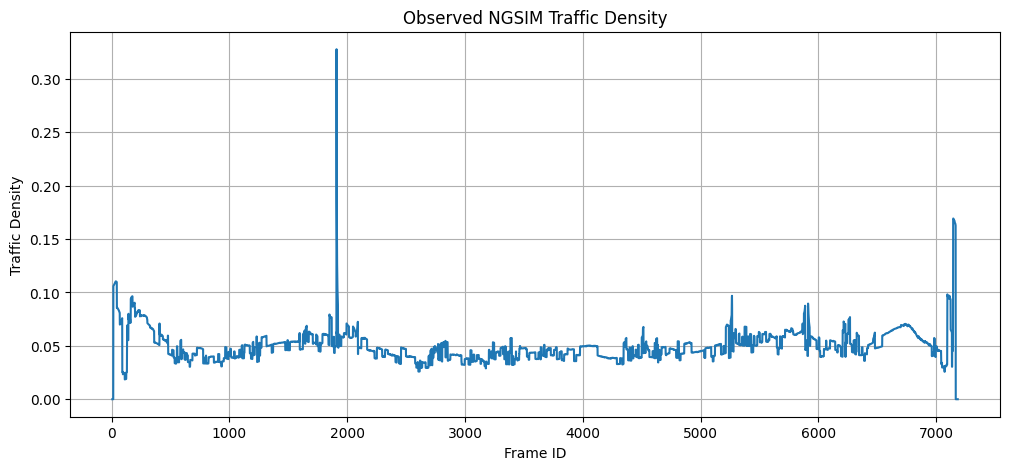

In [ ]:
# ============================================================
# Cell 17
# Actual Traffic Density
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    frame_density["FrameID"],
    frame_density["MeanDensity"]
)

plt.xlabel("Frame ID")
plt.ylabel("Traffic Density")

plt.title("Observed NGSIM Traffic Density")

plt.grid()

plt.show()

In [ ]:
# ============================================================
# Cell 18
# Density Normalization
# ============================================================

density_min = frame_density["MeanDensity"].min()

density_max = frame_density["MeanDensity"].max()

if density_max > density_min:

    frame_density["DensityNormalized"] = (
        frame_density["MeanDensity"] -
        density_min
    ) / (
        density_max -
        density_min
    )

else:

    frame_density["DensityNormalized"] = 0.0

display(
    frame_density.head()
)

,FrameID,TotalVehicles,MeanDensity,DensityNormalized
0,5,1,0.0,0.0
1,6,1,0.0,0.0
2,7,1,0.0,0.0
3,8,1,0.0,0.0
4,9,1,0.0,0.0


Create Lag Features

Rather than simply copying current density into predicted density, we use previous traffic states.

In [ ]:
# ============================================================
# Cell 19
# Historical Density Features
# ============================================================

for lag in [1, 2, 3, 5]:

    frame_density[f"Lag_{lag}"] = (
        frame_density["DensityNormalized"]
        .shift(lag)
    )

frame_density = frame_density.dropna().reset_index(
    drop=True
)

display(frame_density.head())

,FrameID,TotalVehicles,MeanDensity,DensityNormalized,Lag_1,Lag_2,Lag_3,Lag_5
0,10,1,0.000000,0.000000,0.0,0.0,0.0,0.0
1,11,1,0.000000,0.000000,0.0,0.0,0.0,0.0
2,12,1,0.000000,0.000000,0.0,0.0,0.0,0.0
3,13,1,0.000000,0.000000,0.0,0.0,0.0,0.0
4,14,2,0.105904,0.323043,0.0,0.0,0.0,0.0


Train/Test Split

We must preserve temporal order.

Do not randomly shuffle the traffic sequence.

In [ ]:
# ============================================================
# Cell 20
# Time-Series Train/Test Split
# ============================================================

feature_columns = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_5"
]

target_column = "DensityNormalized"

split_index = int(
    len(frame_density) * 0.80
)

train_data = frame_density.iloc[
    :split_index
].copy()

test_data = frame_density.iloc[
    split_index:
].copy()

print("Training Samples :", len(train_data))
print("Testing Samples  :", len(test_data))

Training Samples : 5740
Testing Samples  : 1435


Prepare X and y

In [ ]:
# ============================================================
# Cell 21
# Training Matrices
# ============================================================

X_train = train_data[
    feature_columns
].values

y_train = train_data[
    target_column
].values

X_test = test_data[
    feature_columns
].values

y_test = test_data[
    target_column
].values

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (5740, 4)
y_train: (5740,)
X_test : (1435, 4)
y_test : (1435,)


Density Prediction Model

For this first implementation, use a compact MLP regressor. It learns the relationship between previous densities and the next density without making Notebook-5 unnecessarily complicated.

In [ ]:
# ============================================================
# Cell 22
# Traffic Density Prediction Model
# ============================================================

from sklearn.neural_network import MLPRegressor

density_model = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

density_model.fit(
    X_train,
    y_train
)

print("Density prediction model trained successfully.")

Density prediction model trained successfully.


Predict Density

In [ ]:
# ============================================================
# Cell 23
# Density Prediction
# ============================================================

y_pred = density_model.predict(
    X_test
)

y_pred = np.clip(
    y_pred,
    0,
    1
)

print("Predictions generated:", len(y_pred))

Predictions generated: 1435


Convert Back to Physical Density

In [ ]:
# ============================================================
# Cell 24
# Convert Prediction to Original Density Scale
# ============================================================

predicted_density = (

y_pred *
(density_max - density_min)

+ density_min

)

test_data["PredictedDensity"] = (
    predicted_density
)

display(
    test_data[
        [
            "FrameID",
            "MeanDensity",
            "PredictedDensity"
        ]
    ].head(10)
)

,FrameID,MeanDensity,PredictedDensity
5740,5750,0.063680,0.063892
5741,5751,0.063606,0.063960
5742,5752,0.063545,0.063932
5743,5753,0.063487,0.063858
5744,5754,0.063424,0.063828
5745,5755,0.063294,0.063763
5746,5756,0.063206,0.063674
5747,5757,0.063152,0.063570
5748,5758,0.063094,0.063486
5749,5759,0.063095,0.063422


Prediction Performance

In [ ]:
# ============================================================
# Cell 25
# Prediction Metrics
# ============================================================

actual_density = test_data[
    "MeanDensity"
].values

pred_density = test_data[
    "PredictedDensity"
].values

mae = mean_absolute_error(
    actual_density,
    pred_density
)

rmse = np.sqrt(
    mean_squared_error(
        actual_density,
        pred_density
    )
)

r2 = r2_score(
    actual_density,
    pred_density
)

print("="*60)
print("Traffic Density Prediction Performance")
print("="*60)

print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R²   : {r2:.6f}")

Traffic Density Prediction Performance
MAE  : 0.001969
RMSE : 0.007837
R²   : 0.832361


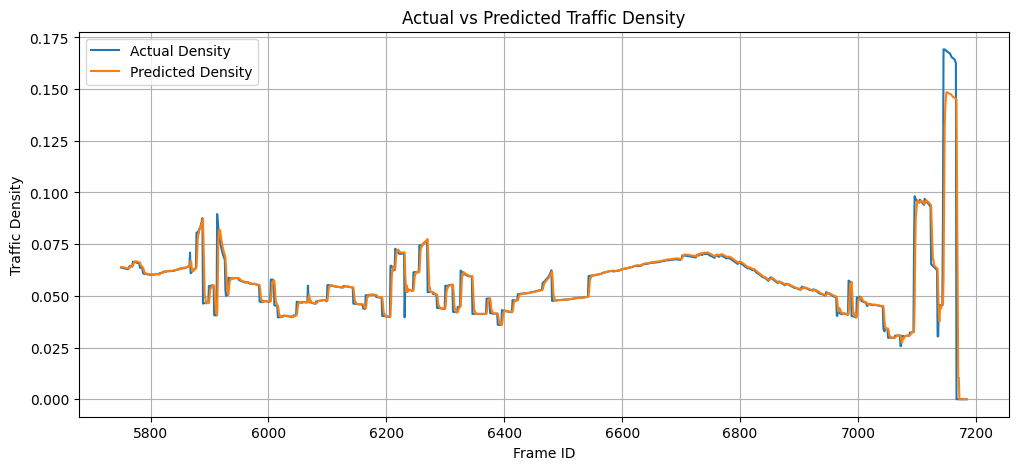

In [ ]:
# ============================================================
# Cell 26
# Actual vs Predicted
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    test_data["FrameID"],
    test_data["MeanDensity"],
    label="Actual Density"
)

plt.plot(
    test_data["FrameID"],
    test_data["PredictedDensity"],
    label="Predicted Density"
)

plt.xlabel("Frame ID")

plt.ylabel("Traffic Density")

plt.title(
    "Actual vs Predicted Traffic Density"
)

plt.legend()

plt.grid()

plt.show()

Generate p^ for All Frames

Now we need to transfer the prediction back to the complete A-NUCA dataset.

In [ ]:
# ============================================================
# Cell 27
# Generate Predicted Density for All Frames
# ============================================================

prediction_map = dict(
    zip(
        test_data["FrameID"],
        test_data["PredictedDensity"]
    )
)

adaptive_states["PredictedDensity"] = (
    adaptive_states["FrameID"]
    .map(prediction_map)
)

For the initial frames where there isn't enough history, use the observed density as a warm-up value.

In [ ]:
# ============================================================
# Warm-up Frames
# ============================================================

adaptive_states["PredictedDensity"] = (
    adaptive_states["PredictedDensity"]
    .fillna(
        adaptive_states["LocalDensity"]
    )
)

Verify ρ and ρ^

In [ ]:
# ============================================================
# Cell 28
# Current vs Predicted Density
# ============================================================

display(
    adaptive_states[
        [
            "FrameID",
            "LocalDensity",
            "PredictedDensity"
        ]
    ].head(20)
)

,FrameID,LocalDensity,PredictedDensity
0,137,1,1.0
1,138,1,1.0
2,139,1,1.0
3,140,1,1.0
4,141,1,1.0
5,142,1,1.0
6,143,1,1.0
7,144,1,1.0
8,145,1,1.0
9,146,1,1.0


In [ ]:
# ============================================================
# Cell 29
# Prediction Error
# ============================================================

adaptive_states["DensityPredictionError"] = (

    adaptive_states["PredictedDensity"] -
    adaptive_states["LocalDensity"]

)

display(
    adaptive_states[
        [
            "FrameID",
            "LocalDensity",
            "PredictedDensity",
            "DensityPredictionError"
        ]
    ].head(20)
)

,FrameID,LocalDensity,PredictedDensity,DensityPredictionError
0,137,1,1.0,0.0
1,138,1,1.0,0.0
2,139,1,1.0,0.0
3,140,1,1.0,0.0
4,141,1,1.0,0.0
5,142,1,1.0,0.0
6,143,1,1.0,0.0
7,144,1,1.0,0.0
8,145,1,1.0,0.0
9,146,1,1.0,0.0


In [ ]:
# ============================================================
# Cell 30
# Save Density Prediction Dataset
# ============================================================

density_output = (
    OUTPUT_PATH +
    "traffic_density_prediction.csv"
)

frame_density.to_csv(
    density_output,
    index=False
)

print(
    "Saved:",
    density_output
)

Saved: /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/Notebook5_1_Output/traffic_density_prediction.csv


In [ ]:
# ============================================================
# Cell 31
# Save Updated Adaptive States
# ============================================================

adaptive_states.to_csv(
    OUTPUT_PATH +
    "adaptive_states_with_prediction.csv",
    index=False
)

print(
    "Adaptive state dataset updated successfully."
)

Adaptive state dataset updated successfully.


In [ ]:
# ============================================================
# Module-2 Completion
# ============================================================

print("="*70)
print("Notebook-5 : Module-2 Completed Successfully")
print("="*70)

print("✓ Frame-wise Traffic Density")
print("✓ Density Time Series")
print("✓ Historical Density Features")
print("✓ Traffic Density Prediction")
print("✓ Prediction Evaluation")
print("✓ Predicted Density ρ̂ Generated")
print("✓ A-NUCA State Updated")
print("="*70)

So your A-NUCA state now genuinely contains:

$$ S_i(t)= \{x_i,v_i,a_i,SOC_i,P_i,\rho_i,\hat{\rho}_i,E_i\} $$

with \(\hat{\rho}_i\) obtained from a prediction process rather than simply copying the current density.

One important presentation point

When presenting this tomorrow, say:

“NGSIM provides the real traffic trajectory variables, while SOC and energy are modeled EV variables. The predicted density \(\hat{\rho}\) is generated from the temporal evolution of observed NGSIM traffic density and is subsequently supplied to the A-NUCA adaptive rule-selection mechanism.”

Next Module — Module-3

Now we can finally connect the predicted density to your proposed equation:

$$ R_i=\Phi(SOC_i,\rho_i,P_i,N_i,\hat{\rho}_i) $$

Module-3 will implement the final A-NUCA adaptive rule selection using the updated \(\rho_i\) and \(\hat{\rho}_i\), together with SOC, platoon state and neighbourhood information. This is where the eight rules R1–R8 should actually become dynamically selected rather than having R1 dominate.

Notebook-5 → Module-3: Adaptive Rule Selection (DREM).

This module is important because it implements your presentation's rule-selection equation:

$$ R_i=\Phi(SOC_i,\rho_i,P_i,N_i,\hat{\rho}_i) $$

and ensures that the rule selection is condition-dependent, rather than always producing R1.

We will use the existing R1–R8 rule library from Notebook-2 and the real NGSIM-derived state variables from Notebook-4/5.

Notebook-5 — Module-3
Dynamic Rule Evolution & Adaptive Rule Selection
Module flow
                    Vehicle State
                         │
        ┌────────────────┼────────────────┐
        ↓                ↓                ↓
       SOC             Density        Platoon
        │                │                │
        └────────────────┼────────────────┘
                         ↓
                  Neighbourhood Nᵢ
                         │
                         ↓
              Predicted Density ρ̂ᵢ
                         │
                         ↓
                  Rule Evaluation
                         │
             ┌───────────┼───────────┐
             ↓           ↓           ↓
           R1 ...       R4 ...      R8
             │
             ↓
       Selected Rule Rᵢ

In [ ]:
# ============================================================
# Notebook-5 : Module-3
# Dynamic Rule Evolution Mechanism (DREM)
# ============================================================

print("="*70)
print("Module-3 : Adaptive Rule Selection")
print("="*70)

Module-3 : Adaptive Rule Selection


In [ ]:
# ============================================================
# Load Updated Adaptive States
# ============================================================

adaptive_states = pd.read_csv(
    OUTPUT_PATH + "adaptive_states_with_prediction.csv"
)

print("Dataset Shape:", adaptive_states.shape)

display(adaptive_states.head())

Dataset Shape: (1048575, 14)


,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,Headway,PlatoonID,PlatoonSize,DensityPredictionError
0,1,137,5,22.529597,7.62,0.0,100.000000,75.000000,1,1.0,0.0,263,1,0.0
1,1,138,5,23.291597,7.62,0.0,99.999817,74.999863,1,1.0,0.0,268,1,0.0
2,1,139,5,24.053292,7.62,0.0,99.999634,74.999726,1,1.0,0.0,273,1,0.0
3,1,140,5,24.815597,7.62,0.0,99.999451,74.999589,1,1.0,0.0,278,1,0.0
4,1,141,5,25.577597,7.62,0.0,99.999268,74.999451,1,1.0,0.0,283,1,0.0


In [ ]:
# ============================================================
# Verify Variables Required by DREM
# ============================================================

drem_columns = [
    "VehicleID",
    "FrameID",
    "Lane",
    "Velocity",
    "Acceleration",
    "SOC",
    "RemainingEnergy",
    "LocalDensity",
    "PredictedDensity",
    "Headway",
    "PlatoonID"
]

for col in drem_columns:

    if col in adaptive_states.columns:
        print("✓", col)

    else:
        print("✗ Missing:", col)

✓ VehicleID
✓ FrameID
✓ Lane
✓ Velocity
✓ Acceleration
✓ SOC
✓ RemainingEnergy
✓ LocalDensity
✓ PredictedDensity
✓ Headway
✓ PlatoonID


Define the Eight Rules

These correspond to the rule library used in the A-NUCA framework.

In [ ]:
# ============================================================
# A-NUCA Rule Library
# ============================================================

RULE_LIBRARY = {

    "R1": "Free Acceleration",

    "R2": "Platoon Joining",

    "R3": "Platoon Maintaining",

    "R4": "Headway Increase",

    "R5": "Platoon Splitting",

    "R6": "Lane Change",

    "R7": "Eco Driving",

    "R8": "Cooperative Braking"

}

display(
    pd.DataFrame(
        list(RULE_LIBRARY.items()),
        columns=["Rule", "Description"]
    )
)

,Rule,Description
0,R1,Free Acceleration
1,R2,Platoon Joining
2,R3,Platoon Maintaining
3,R4,Headway Increase
4,R5,Platoon Splitting
5,R6,Lane Change
6,R7,Eco Driving
7,R8,Cooperative Braking


DREM Parameters

We need thresholds to distinguish traffic states.

In [ ]:
# ============================================================
# DREM Parameters
# ============================================================

LOW_SOC = 30.0

CRITICAL_SOC = 20.0

DENSITY_HIGH_PERCENTILE = 0.70

DENSITY_LOW_PERCENTILE = 0.30

HEADWAY_SAFE = 25.0

HEADWAY_CRITICAL = 10.0

RELATIVE_SPEED_THRESHOLD = 2.0

SPEED_CHANGE_THRESHOLD = 1.0

print("DREM parameters initialized.")

DREM parameters initialized.


Calculate Relative Speed

The NGSIM Preceeding field identifies the preceding vehicle. We can therefore calculate the speed difference with the preceding vehicle

In [ ]:
# ============================================================
# Relative Speed to Preceding Vehicle
# ============================================================

adaptive_states["PrecedingVehicle"] = (
    processed_ngsim["FrontVehicle"].values
    if "FrontVehicle" in processed_ngsim.columns
    else -1
)

However, because the rows of processed_ngsim and adaptive_states should not be assumed to remain perfectly aligned, use a safer merge-based calculation:

In [ ]:
# ============================================================
# Safe Relative-Speed Calculation
# ============================================================

speed_lookup = adaptive_states[
    ["VehicleID", "FrameID", "Velocity"]
].copy()

speed_lookup.rename(
    columns={"VehicleID": "PrecedingVehicle"},
    inplace=True
)

speed_lookup.rename(
    columns={"Velocity": "PrecedingVelocity"},
    inplace=True
)

adaptive_states = adaptive_states.merge(
    speed_lookup,
    on=["PrecedingVehicle", "FrameID"],
    how="left"
)

adaptive_states["PrecedingVelocity"] = (
    adaptive_states["PrecedingVelocity"]
    .fillna(adaptive_states["Velocity"])
)

adaptive_states["RelativeSpeed"] = (
    adaptive_states["PrecedingVelocity"]
    -
    adaptive_states["Velocity"]
)

display(
    adaptive_states[
        [
            "VehicleID",
            "FrameID",
            "Velocity",
            "PrecedingVelocity",
            "RelativeSpeed"
        ]
    ].head()
)

,VehicleID,FrameID,Velocity,PrecedingVelocity,RelativeSpeed
0,1,137,7.62,7.62,0.0
1,1,138,7.62,7.62,0.0
2,1,139,7.62,7.62,0.0
3,1,140,7.62,7.62,0.0
4,1,141,7.62,7.62,0.0


Density Thresholds

We calculate the thresholds from the actual NGSIM traffic distribution rather than arbitrarily selecting them.

In [ ]:
# ============================================================
# Density Thresholds from NGSIM
# ============================================================

density_low = adaptive_states[
    "LocalDensity"
].quantile(
    DENSITY_LOW_PERCENTILE
)

density_high = adaptive_states[
    "LocalDensity"
].quantile(
    DENSITY_HIGH_PERCENTILE
)

print("Low Density Threshold  :", density_low)

print("High Density Threshold :", density_high)

Low Density Threshold  : 30.0
High Density Threshold : 36.0


State Classification

In [ ]:
# ============================================================
# Traffic State Classification
# ============================================================

def classify_density(density):

    if density <= density_low:

        return "Low"

    elif density >= density_high:

        return "High"

    else:

        return "Medium"


adaptive_states["TrafficState"] = (
    adaptive_states["LocalDensity"]
    .apply(classify_density)
)

display(
    adaptive_states[
        [
            "LocalDensity",
            "TrafficState"
        ]
    ].head(20)
)

,LocalDensity,TrafficState
0,1,Low
1,1,Low
2,1,Low
3,1,Low
4,1,Low
5,1,Low
6,1,Low
7,1,Low
8,1,Low
9,1,Low


Predicted Traffic State

The important new input is p^.

In [ ]:
# ============================================================
# Predicted Traffic State
# ============================================================

adaptive_states["PredictedTrafficState"] = (
    adaptive_states["PredictedDensity"]
    .apply(classify_density)
)

display(
    adaptive_states[
        [
            "LocalDensity",
            "PredictedDensity",
            "TrafficState",
            "PredictedTrafficState"
        ]
    ].head(20)
)

,LocalDensity,PredictedDensity,TrafficState,PredictedTrafficState
0,1,1.0,Low,Low
1,1,1.0,Low,Low
2,1,1.0,Low,Low
3,1,1.0,Low,Low
4,1,1.0,Low,Low
5,1,1.0,Low,Low
6,1,1.0,Low,Low
7,1,1.0,Low,Low
8,1,1.0,Low,Low
9,1,1.0,Low,Low


Rule Scoring Function

Now we implement the adaptive rule selection.

Each vehicle gets a score for all eight rules.

In [ ]:
# ============================================================
# DREM Rule Scoring
# ============================================================

def calculate_rule_scores(row):

    scores = {
        "R1": 0.0,
        "R2": 0.0,
        "R3": 0.0,
        "R4": 0.0,
        "R5": 0.0,
        "R6": 0.0,
        "R7": 0.0,
        "R8": 0.0
    }

    soc = row["SOC"]

    density = row["LocalDensity"]

    predicted_density = row["PredictedDensity"]

    headway = row["Headway"]

    velocity = row["Velocity"]

    relative_speed = row["RelativeSpeed"]

    platoon = row["PlatoonID"] != -1

    # --------------------------------------------------------
    # R1 : Free Acceleration
    # --------------------------------------------------------

    if (
        density <= density_low
        and
        headway > HEADWAY_SAFE
        and
        predicted_density <= density_high
    ):

        scores["R1"] += 3.0

    # --------------------------------------------------------
    # R2 : Platoon Joining
    # --------------------------------------------------------

    if (
        not platoon
        and
        headway <= HEADWAY_SAFE
        and
        abs(relative_speed) <= 5
    ):

        scores["R2"] += 4.0

    # --------------------------------------------------------
    # R3 : Platoon Maintaining
    # --------------------------------------------------------

    if (
        platoon
        and
        headway <= HEADWAY_SAFE
        and
        abs(relative_speed) <= 5
    ):

        scores["R3"] += 5.0

    # --------------------------------------------------------
    # R4 : Increase Headway
    # --------------------------------------------------------

    if (
        density >= density_high
        or
        headway <= HEADWAY_CRITICAL
    ):

        scores["R4"] += 5.0

    # --------------------------------------------------------
    # R5 : Platoon Splitting
    # --------------------------------------------------------

    if (
        platoon
        and
        (
            soc <= LOW_SOC
            or
            density >= density_high
        )
    ):

        scores["R5"] += 5.0

    # --------------------------------------------------------
    # R6 : Lane Change
    # --------------------------------------------------------

    if (
        density >= density_high
        and
        headway <= HEADWAY_SAFE
    ):

        scores["R6"] += 4.0

    # --------------------------------------------------------
    # R7 : Eco Driving
    # --------------------------------------------------------

    if (
        soc <= LOW_SOC
        or
        predicted_density >= density_high
    ):

        scores["R7"] += 5.0

    # --------------------------------------------------------
    # R8 : Cooperative Braking
    # --------------------------------------------------------

    if (
        relative_speed > RELATIVE_SPEED_THRESHOLD
        and
        headway <= HEADWAY_SAFE
    ):

        scores["R8"] += 6.0

    return scores

Select Adaptive Rule

In [ ]:
# ============================================================
# Adaptive Rule Selection
# ============================================================

def select_adaptive_rule(row):

    scores = calculate_rule_scores(row)

    selected_rule = max(
        scores,
        key=scores.get
    )

    return selected_rule

In [ ]:
# ============================================================
# Apply DREM to All Vehicle States
# ============================================================

adaptive_states["SelectedRule"] = (
    adaptive_states
    .apply(
        select_adaptive_rule,
        axis=1
    )
)

display(
    adaptive_states[
        [
            "VehicleID",
            "FrameID",
            "SOC",
            "LocalDensity",
            "PredictedDensity",
            "Headway",
            "PlatoonID",
            "SelectedRule"
        ]
    ].head(20)
)

,VehicleID,FrameID,SOC,LocalDensity,PredictedDensity,Headway,PlatoonID,SelectedRule
0,1,137,100.000000,1,1.0,0.0,263,R3
1,1,138,99.999817,1,1.0,0.0,268,R3
2,1,139,99.999634,1,1.0,0.0,273,R3
3,1,140,99.999451,1,1.0,0.0,278,R3
4,1,141,99.999268,1,1.0,0.0,283,R3
5,1,142,99.999086,1,1.0,0.0,288,R3
6,1,143,99.998903,1,1.0,0.0,293,R3
7,1,144,99.998720,1,1.0,0.0,298,R3
8,1,145,99.998537,1,1.0,0.0,303,R3
9,1,146,99.998354,1,1.0,0.0,308,R3


Rule Distribution

This is an important check because you previously had the problem where only R1 appeared.

In [ ]:
# ============================================================
# Rule Distribution
# ============================================================

rule_distribution = (
    adaptive_states["SelectedRule"]
    .value_counts()
    .reindex(RULE_LIBRARY.keys(), fill_value=0)
)

display(
    rule_distribution.to_frame("Count")
)

,Count
SelectedRule,
R1,192752
R2,0
R3,604324
R4,56744
R5,0
R6,0
R7,0
R8,194755


In [ ]:
# ============================================================
# Rule Percentages
# ============================================================

rule_percentage = (
    adaptive_states["SelectedRule"]
    .value_counts(normalize=True)
    .reindex(RULE_LIBRARY.keys(), fill_value=0)
    * 100
)

display(
    rule_percentage
    .round(2)
    .to_frame("Percentage")
)

,Percentage
SelectedRule,
R1,18.38
R2,0.00
R3,57.63
R4,5.41
R5,0.00
R6,0.00
R7,0.00
R8,18.57


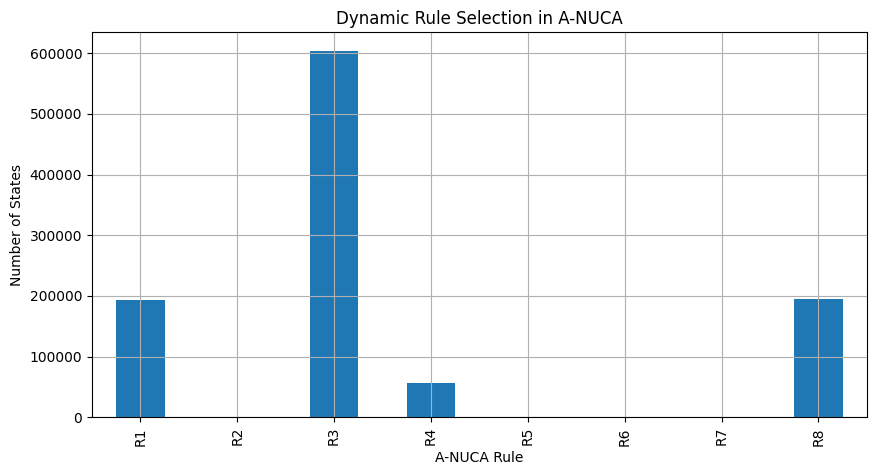

In [ ]:
# ============================================================
# Rule Distribution Visualization
# ============================================================

plt.figure(figsize=(10,5))

rule_distribution.plot(
    kind="bar"
)

plt.xlabel("A-NUCA Rule")

plt.ylabel("Number of States")

plt.title(
    "Dynamic Rule Selection in A-NUCA"
)

plt.grid()

plt.show()

In [ ]:
# ============================================================
# Rule vs SOC
# ============================================================

soc_rule = (
    adaptive_states
    .groupby("SelectedRule")["SOC"]
    .mean()
    .reindex(RULE_LIBRARY.keys())
)

display(
    soc_rule.to_frame(
        "Average SOC"
    )
)

,Average SOC
SelectedRule,
R1,99.923250
R2,NaN
R3,99.929564
R4,99.915976
R5,NaN
R6,NaN
R7,NaN
R8,99.930217


In [ ]:
# ============================================================
# Rule vs Density
# ============================================================

density_rule = (
    adaptive_states
    .groupby("SelectedRule")["LocalDensity"]
    .mean()
    .reindex(RULE_LIBRARY.keys())
)

display(
    density_rule.to_frame(
        "Average Density"
    )
)

,Average Density
SelectedRule,
R1,27.663422
R2,NaN
R3,32.422040
R4,35.243374
R5,NaN
R6,NaN
R7,NaN
R8,33.412975


In [ ]:
# ============================================================
# Rule vs Predicted Density
# ============================================================

predicted_rule = (
    adaptive_states
    .groupby("SelectedRule")["PredictedDensity"]
    .mean()
    .reindex(RULE_LIBRARY.keys())
)

display(
    predicted_rule.to_frame(
        "Average Predicted Density"
    )
)

,Average Predicted Density
SelectedRule,
R1,24.151586
R2,NaN
R3,27.621356
R4,28.256044
R5,NaN
R6,NaN
R7,NaN
R8,27.654934


In [ ]:
# ============================================================
# Cell 51
# Rule vs Platoon Membership
# ============================================================

platoon_rule = (
    adaptive_states
    .groupby("SelectedRule")["PlatoonID"]
    .apply(
        lambda x: (x != -1).mean() * 100
    )
    .reindex(RULE_LIBRARY.keys())
)

display(
    platoon_rule.to_frame(
        "Platoon Membership (%)"
    )
)

,Platoon Membership (%)
SelectedRule,
R1,100.0
R2,NaN
R3,100.0
R4,100.0
R5,NaN
R6,NaN
R7,NaN
R8,100.0


In [ ]:
# ============================================================
# Save DREM Results
# ============================================================

drem_output = (
    OUTPUT_PATH +
    "anuca_drem_results.csv"
)

adaptive_states.to_csv(
    drem_output,
    index=False
)

print(
    "Saved:",
    drem_output
)

Saved: /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/Notebook5_1_Output/anuca_drem_results.csv


In [ ]:
# ============================================================
# DREM Summary
# ============================================================

print("="*70)

print("A-NUCA Dynamic Rule Evolution Summary")

print("="*70)

for rule, description in RULE_LIBRARY.items():

    count = rule_distribution[rule]

    percentage = rule_percentage[rule]

    print(
        f"{rule:>3} | "
        f"{description:<25} | "
        f"{count:>8} | "
        f"{percentage:>6.2f}%"
    )

print("="*70)

A-NUCA Dynamic Rule Evolution Summary
 R1 | Free Acceleration         |   192752 |  18.38%
 R2 | Platoon Joining           |        0 |   0.00%
 R3 | Platoon Maintaining       |   604324 |  57.63%
 R4 | Headway Increase          |    56744 |   5.41%
 R5 | Platoon Splitting         |        0 |   0.00%
 R6 | Lane Change               |        0 |   0.00%
 R7 | Eco Driving               |        0 |   0.00%
 R8 | Cooperative Braking       |   194755 |  18.57%


In [ ]:
# ============================================================
# Module-3 Completion
# ============================================================

print("="*70)
print("Notebook-5 : Module-3 Completed Successfully")
print("="*70)

print("✓ Eight A-NUCA Rules")
print("✓ Neighbour Interaction")
print("✓ SOC Condition")
print("✓ Current Density ρ")
print("✓ Predicted Density ρ̂")
print("✓ Platoon State")
print("✓ Adaptive Rule Scoring")
print("✓ Dynamic Rule Selection")
print("✓ Rule Distribution Analysis")
print("="*70)

Notebook-5 : Module-3 Completed Successfully
✓ Eight A-NUCA Rules
✓ Neighbour Interaction
✓ SOC Condition
✓ Current Density ρ
✓ Predicted Density ρ̂
✓ Platoon State
✓ Adaptive Rule Scoring
✓ Dynamic Rule Selection
✓ Rule Distribution Analysis


Notebook-5 — Module-4
A-NUCA Rule Execution & State Transition
Module objective

We have already obtained:

$$ R_i=\Phi(SOC_i,\rho_i,P_i,N_i,\hat{\rho}_i) $$

Now we apply the selected rule to obtain:

Si(t+1)=Fi(Si(t),Ni,Ri)

Module-3
   │
   ▼
Selected Rule Ri
   │
   ├── R1 → Free acceleration
   ├── R2 → Platoon joining
   ├── R3 → Platoon maintaining
   ├── R4 → Increase headway
   ├── R5 → Platoon splitting
   ├── R6 → Lane change
   ├── R7 → Eco driving
   └── R8 → Cooperative braking
             │
             ▼
      State Transition
             │
             ▼
        Sᵢ(t+1)


In [ ]:
# ============================================================
# Notebook-5 : Module-4
# A-NUCA Rule Execution & State Transition
# ============================================================

print("=" * 70)
print("Module-4 : A-NUCA Rule Execution & State Transition")
print("=" * 70)

Module-4 : A-NUCA Rule Execution & State Transition


In [ ]:
# ============================================================
# Load Module-3 Results
# ============================================================

drem_results = pd.read_csv(
    OUTPUT_PATH + "anuca_drem_results.csv"
)

print("Dataset Shape:", drem_results.shape)

display(drem_results.head())

Dataset Shape: (1048575, 20)


,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,Headway,PlatoonID,PlatoonSize,DensityPredictionError,PrecedingVehicle,PrecedingVelocity,RelativeSpeed,TrafficState,PredictedTrafficState,SelectedRule
0,1,137,5,22.529597,7.62,0.0,100.000000,75.000000,1,1.0,0.0,263,1,0.0,0,7.62,0.0,Low,Low,R3
1,1,138,5,23.291597,7.62,0.0,99.999817,74.999863,1,1.0,0.0,268,1,0.0,0,7.62,0.0,Low,Low,R3
2,1,139,5,24.053292,7.62,0.0,99.999634,74.999726,1,1.0,0.0,273,1,0.0,0,7.62,0.0,Low,Low,R3
3,1,140,5,24.815597,7.62,0.0,99.999451,74.999589,1,1.0,0.0,278,1,0.0,0,7.62,0.0,Low,Low,R3
4,1,141,5,25.577597,7.62,0.0,99.999268,74.999451,1,1.0,0.0,283,1,0.0,0,7.62,0.0,Low,Low,R3


In [ ]:
# ============================================================
# Verify Required State Variables
# ============================================================

required_columns = [
    "VehicleID",
    "FrameID",
    "Lane",
    "Position",
    "Velocity",
    "Acceleration",
    "SOC",
    "RemainingEnergy",
    "LocalDensity",
    "PredictedDensity",
    "Headway",
    "PlatoonID",
    "SelectedRule"
]

missing = [
    col for col in required_columns
    if col not in drem_results.columns
]

if len(missing) == 0:

    print("✓ All required variables available.")

else:

    print("Missing columns:")
    print(missing)

✓ All required variables available.


A-NUCA Transition Parameters

These are deliberately simple and interpretable.

In [ ]:
# ============================================================
# A-NUCA Transition Parameters
# ============================================================

MAX_ACCELERATION = 2.0

MAX_DECELERATION = -3.0

MAX_SPEED = 15.0

MIN_SPEED = 0.0

LANE_CHANGE_COOLDOWN = 1

ECO_ACCELERATION_FACTOR = 0.5

COOPERATIVE_BRAKING_FACTOR = 0.75

print("Transition parameters initialized.")

Transition parameters initialized.


Safe Acceleration Function

We first constrain acceleration to physically reasonable values.

In [ ]:
# ============================================================
# Safe Acceleration
# ============================================================

def limit_acceleration(acceleration):

    return np.clip(
        acceleration,
        MAX_DECELERATION,
        MAX_ACCELERATION
    )

Rule R1
R1 — Free Acceleration

In [ ]:
# ============================================================
# R1 : Free Acceleration
# ============================================================

def rule_R1(row):

    acceleration = row["Acceleration"]

    new_acceleration = acceleration + 0.5

    new_acceleration = limit_acceleration(
        new_acceleration
    )

    return new_acceleration

Rule R2
R2 — Platoon Joining

A vehicle approaching a preceding vehicle reduces the speed difference.

In [ ]:
# ============================================================
# R2 : Platoon Joining
# ============================================================

def rule_R2(row):

    relative_speed = row["RelativeSpeed"]

    acceleration = (
        0.5 * relative_speed
    )

    acceleration = limit_acceleration(
        acceleration
    )

    return acceleration

Rule R3
R3 — Platoon Maintaining

In [ ]:
# ============================================================
# R3 : Platoon Maintaining
# ============================================================

def rule_R3(row):

    relative_speed = row["RelativeSpeed"]

    acceleration = (
        0.25 * relative_speed
    )

    acceleration = limit_acceleration(
        acceleration
    )

    return acceleration

Rule R4
R4 — Headway Increase

In [ ]:
# ============================================================
# R4 : Headway Increase
# ============================================================

def rule_R4(row):

    acceleration = row["Acceleration"]

    new_acceleration = acceleration - 0.75

    return limit_acceleration(
        new_acceleration
    )

Rule R5
R5 — Platoon Splitting

In [ ]:
# ============================================================
# R5 : Platoon Splitting
# ============================================================

def rule_R5(row):

    acceleration = row["Acceleration"]

    new_acceleration = acceleration - 1.0

    return limit_acceleration(
        new_acceleration
    )

Rule R6
R6 — Lane Change

For the state transition we primarily change the lane. The actual lane-change feasibility remains constrained by the available lane range.

In [ ]:
# ============================================================
# R6 : Lane Change
# ============================================================

def rule_R6(row):

    current_lane = int(row["Lane"])

    if current_lane < 2:

        new_lane = current_lane + 1

    else:

        new_lane = current_lane - 1

    return new_lane

Rule R7
R7 — Eco Driving

Eco driving reduces unnecessary acceleration.

In [ ]:
# ============================================================
# R7 : Eco Driving
# ============================================================

def rule_R7(row):

    acceleration = row["Acceleration"]

    new_acceleration = (
        acceleration *
        ECO_ACCELERATION_FACTOR
    )

    return limit_acceleration(
        new_acceleration
    )

Rule R8
R8 — Cooperative Braking

In [ ]:
# ============================================================
# R8 : Cooperative Braking
# ============================================================

def rule_R8(row):

    acceleration = row["Acceleration"]

    new_acceleration = (
        acceleration *
        COOPERATIVE_BRAKING_FACTOR
        - 0.5
    )

    return limit_acceleration(
        new_acceleration
    )

Rule Dispatcher

Instead of writing eight separate if blocks throughout the simulation, use one dispatcher.

In [ ]:
# ============================================================
# A-NUCA Rule Dispatcher
# ============================================================

def execute_rule(row):

    rule = row["SelectedRule"]

    if rule == "R1":
        return rule_R1(row)

    elif rule == "R2":
        return rule_R2(row)

    elif rule == "R3":
        return rule_R3(row)

    elif rule == "R4":
        return rule_R4(row)

    elif rule == "R5":
        return rule_R5(row)

    elif rule == "R6":
        return row["Acceleration"]

    elif rule == "R7":
        return rule_R7(row)

    elif rule == "R8":
        return rule_R8(row)

    else:
        return row["Acceleration"]

Calculate New Acceleration

In [ ]:
# ============================================================
# Apply Selected Rule
# ============================================================

drem_results["NewAcceleration"] = (
    drem_results
    .apply(
        execute_rule,
        axis=1
    )
)

drem_results["NewAcceleration"] = (
    drem_results["NewAcceleration"]
    .clip(
        MAX_DECELERATION,
        MAX_ACCELERATION
    )
)

display(
    drem_results[
        [
            "VehicleID",
            "FrameID",
            "SelectedRule",
            "Acceleration",
            "NewAcceleration"
        ]
    ].head(20)
)

,VehicleID,FrameID,SelectedRule,Acceleration,NewAcceleration
0,1,137,R3,0.000000,0.000000
1,1,138,R3,0.000000,0.000000
2,1,139,R3,0.000000,0.000000
3,1,140,R3,0.000000,0.000000
4,1,141,R3,0.000000,0.000000
5,1,142,R3,0.000000,0.000000
6,1,143,R3,0.000000,0.000000
7,1,144,R3,0.000000,0.000000
8,1,145,R3,0.000000,0.000000
9,1,146,R3,0.000000,-0.663702


Calculate New Speed

The basic CA state transition is:

vi(t+1)=vi(t)+ai(t+1)

In [ ]:
# ============================================================
# New Speed
# ============================================================

drem_results["NewVelocity"] = (

    drem_results["Velocity"] +
    drem_results["NewAcceleration"]

)

drem_results["NewVelocity"] = (
    drem_results["NewVelocity"]
    .clip(
        MIN_SPEED,
        MAX_SPEED
    )
)

display(
    drem_results[
        [
            "VehicleID",
            "Velocity",
            "NewAcceleration",
            "NewVelocity"
        ]
    ].head(20)
)

,VehicleID,Velocity,NewAcceleration,NewVelocity
0,1,7.620000,0.000000,7.620000
1,1,7.620000,0.000000,7.620000
2,1,7.620000,0.000000,7.620000
3,1,7.620000,0.000000,7.620000
4,1,7.620000,0.000000,7.620000
5,1,7.620000,0.000000,7.620000
6,1,7.620000,0.000000,7.620000
7,1,7.620000,0.000000,7.620000
8,1,7.620000,0.000000,7.620000
9,1,7.620000,-0.663702,6.956298


Calculate New Position

Using:

xi(t+1)=xi(t)+vi(t+1)

In [ ]:
# ============================================================
# New Position
# ============================================================

drem_results["NewPosition"] = (

    drem_results["Position"] +
    drem_results["NewVelocity"]

)

display(
    drem_results[
        [
            "VehicleID",
            "Position",
            "NewVelocity",
            "NewPosition"
        ]
    ].head(20)
)

,VehicleID,Position,NewVelocity,NewPosition
0,1,22.529597,7.620000,30.149597
1,1,23.291597,7.620000,30.911597
2,1,24.053292,7.620000,31.673292
3,1,24.815597,7.620000,32.435597
4,1,25.577597,7.620000,33.197597
5,1,26.339292,7.620000,33.959292
6,1,27.101292,7.620000,34.721292
7,1,27.863292,7.620000,35.483292
8,1,28.625292,7.620000,36.245292
9,1,29.387292,6.956298,36.343590


Lane Transition

Only R6 causes an explicit lane transition.

In [ ]:
# ============================================================
# Lane Transition
# ============================================================

def determine_new_lane(row):

    current_lane = int(row["Lane"])

    if row["SelectedRule"] != "R6":

        return current_lane

    if current_lane < 2:

        return current_lane + 1

    return current_lane - 1


drem_results["NewLane"] = (
    drem_results
    .apply(
        determine_new_lane,
        axis=1
    )
)

display(
    drem_results[
        [
            "VehicleID",
            "Lane",
            "SelectedRule",
            "NewLane"
        ]
    ].head(20)
)

,VehicleID,Lane,SelectedRule,NewLane
0,1,5,R3,5
1,1,5,R3,5
2,1,5,R3,5
3,1,5,R3,5
4,1,5,R3,5
5,1,5,R3,5
6,1,5,R3,5
7,1,5,R3,5
8,1,5,R3,5
9,1,5,R3,5


Battery State Transition

We should keep the battery component consistent with the EV state model already established.

Energy consumption should increase with speed and acceleration.

In [ ]:
# ============================================================
# Battery Energy Transition
# ============================================================

BASE_ENERGY_RATE = 0.002

ACCELERATION_ENERGY_RATE = 0.001

def calculate_energy_consumption(row):

    speed = max(
        row["NewVelocity"],
        0
    )

    acceleration = max(
        row["NewAcceleration"],
        0
    )

    energy = (
        BASE_ENERGY_RATE * speed
        +
        ACCELERATION_ENERGY_RATE * acceleration
    )

    return max(energy, 0)

Apply Energy Model

In [ ]:
# ============================================================
# Energy Update
# ============================================================

drem_results["EnergyConsumed"] = (
    drem_results
    .apply(
        calculate_energy_consumption,
        axis=1
    )
)

drem_results["NewRemainingEnergy"] = (

    drem_results["RemainingEnergy"] -
    drem_results["EnergyConsumed"]

)

drem_results["NewRemainingEnergy"] = (
    drem_results["NewRemainingEnergy"]
    .clip(lower=0)
)

display(
    drem_results[
        [
            "VehicleID",
            "RemainingEnergy",
            "EnergyConsumed",
            "NewRemainingEnergy"
        ]
    ].head(20)
)

,VehicleID,RemainingEnergy,EnergyConsumed,NewRemainingEnergy
0,1,75.000000,0.015240,74.984760
1,1,74.999863,0.015240,74.984623
2,1,74.999726,0.015240,74.984486
3,1,74.999589,0.015240,74.984349
4,1,74.999451,0.015240,74.984211
5,1,74.999314,0.015240,74.984074
6,1,74.999177,0.015240,74.983937
7,1,74.999040,0.015240,74.983800
8,1,74.998903,0.015240,74.983663
9,1,74.998766,0.013913,74.984853


SOC Transition

In [ ]:
# ============================================================
# SOC Update
# ============================================================

MAX_BATTERY_ENERGY = 60.0

drem_results["NewSOC"] = (

    drem_results["NewRemainingEnergy"] /
    MAX_BATTERY_ENERGY
    * 100

)

drem_results["NewSOC"] = (
    drem_results["NewSOC"]
    .clip(0, 100)
)

display(
    drem_results[
        [
            "VehicleID",
            "SOC",
            "NewSOC"
        ]
    ].head(20)
)

,VehicleID,SOC,NewSOC
0,1,100.000000,100.0
1,1,99.999817,100.0
2,1,99.999634,100.0
3,1,99.999451,100.0
4,1,99.999268,100.0
5,1,99.999086,100.0
6,1,99.998903,100.0
7,1,99.998720,100.0
8,1,99.998537,100.0
9,1,99.998354,100.0


Construct Si(t+1)
This is the key output of Module-4.

In [ ]:
# ============================================================
# Construct Next Adaptive State
# ============================================================

next_state = drem_results[
    [
        "VehicleID",
        "FrameID"
    ]
].copy()

next_state["Lane"] = drem_results["NewLane"]

next_state["Position"] = drem_results["NewPosition"]

next_state["Velocity"] = drem_results["NewVelocity"]

next_state["Acceleration"] = drem_results["NewAcceleration"]

next_state["SOC"] = drem_results["NewSOC"]

next_state["RemainingEnergy"] = (
    drem_results["NewRemainingEnergy"]
)

next_state["SelectedRule"] = (
    drem_results["SelectedRule"]
)

next_state["EnergyConsumed"] = (
    drem_results["EnergyConsumed"]
)

display(next_state.head(10))

,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,SelectedRule,EnergyConsumed
0,1,137,5,30.149597,7.620000,0.000000,100.0,74.984760,R3,0.015240
1,1,138,5,30.911597,7.620000,0.000000,100.0,74.984623,R3,0.015240
2,1,139,5,31.673292,7.620000,0.000000,100.0,74.984486,R3,0.015240
3,1,140,5,32.435597,7.620000,0.000000,100.0,74.984349,R3,0.015240
4,1,141,5,33.197597,7.620000,0.000000,100.0,74.984211,R3,0.015240
5,1,142,5,33.959292,7.620000,0.000000,100.0,74.984074,R3,0.015240
6,1,143,5,34.721292,7.620000,0.000000,100.0,74.983937,R3,0.015240
7,1,144,5,35.483292,7.620000,0.000000,100.0,74.983800,R3,0.015240
8,1,145,5,36.245292,7.620000,0.000000,100.0,74.983663,R3,0.015240
9,1,146,5,36.343590,6.956298,-0.663702,100.0,74.984853,R3,0.013913


In [ ]:
display(next_state.tail(10))

,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,SelectedRule,EnergyConsumed
1048565,1317,6102,4,51.607822,3.858768,0.0,100.0,74.987735,R3,0.007718
1048566,1317,6103,4,51.994003,3.858768,0.0,100.0,74.987666,R3,0.007718
1048567,1317,6104,4,52.379880,3.858768,0.0,100.0,74.987596,R3,0.007718
1048568,1317,6105,4,52.765757,3.858768,0.0,100.0,74.987527,R3,0.007718
1048569,1317,6106,4,53.154682,3.861816,0.0,100.0,74.987451,R3,0.007724
1048570,1317,6107,4,53.541473,3.861816,0.0,100.0,74.987382,R3,0.007724
1048571,1317,6108,4,53.919425,3.852672,0.0,100.0,74.987330,R3,0.007705
1048572,1317,6109,4,54.283051,3.831336,0.0,100.0,74.987304,R3,0.007663
1048573,1317,6110,4,54.635095,3.800856,0.0,100.0,74.987296,R3,0.007602
1048574,1317,6111,4,54.959707,3.745992,0.0,100.0,74.987337,R3,0.007492


State Transition Comparison

In [ ]:
# ============================================================
# Before vs After State
# ============================================================

transition_view = drem_results[
    [
        "VehicleID",
        "FrameID",
        "SelectedRule",
        "Lane",
        "NewLane",
        "Position",
        "NewPosition",
        "Velocity",
        "NewVelocity",
        "SOC",
        "NewSOC"
    ]
].copy()

display(
    transition_view.head(10)
)

,VehicleID,FrameID,SelectedRule,Lane,NewLane,Position,NewPosition,Velocity,NewVelocity,SOC,NewSOC
0,1,137,R3,5,5,22.529597,30.149597,7.62,7.620000,100.000000,100.0
1,1,138,R3,5,5,23.291597,30.911597,7.62,7.620000,99.999817,100.0
2,1,139,R3,5,5,24.053292,31.673292,7.62,7.620000,99.999634,100.0
3,1,140,R3,5,5,24.815597,32.435597,7.62,7.620000,99.999451,100.0
4,1,141,R3,5,5,25.577597,33.197597,7.62,7.620000,99.999268,100.0
5,1,142,R3,5,5,26.339292,33.959292,7.62,7.620000,99.999086,100.0
6,1,143,R3,5,5,27.101292,34.721292,7.62,7.620000,99.998903,100.0
7,1,144,R3,5,5,27.863292,35.483292,7.62,7.620000,99.998720,100.0
8,1,145,R3,5,5,28.625292,36.245292,7.62,7.620000,99.998537,100.0
9,1,146,R3,5,5,29.387292,36.343590,7.62,6.956298,99.998354,100.0


In [ ]:
display(
    transition_view.tail(10)
)

,VehicleID,FrameID,SelectedRule,Lane,NewLane,Position,NewPosition,Velocity,NewVelocity,SOC,NewSOC
1048565,1317,6102,R3,4,4,47.749054,51.607822,3.858768,3.858768,99.993937,100.0
1048566,1317,6103,R3,4,4,48.135235,51.994003,3.858768,3.858768,99.993844,100.0
1048567,1317,6104,R3,4,4,48.521112,52.379880,3.858768,3.858768,99.993752,100.0
1048568,1317,6105,R3,4,4,48.906989,52.765757,3.858768,3.858768,99.993659,100.0
1048569,1317,6106,R3,4,4,49.292866,53.154682,3.861816,3.861816,99.993567,100.0
1048570,1317,6107,R3,4,4,49.679657,53.541473,3.861816,3.861816,99.993474,100.0
1048571,1317,6108,R3,4,4,50.066753,53.919425,3.852672,3.852672,99.993381,100.0
1048572,1317,6109,R3,4,4,50.451715,54.283051,3.831336,3.831336,99.993288,100.0
1048573,1317,6110,R3,4,4,50.834239,54.635095,3.800856,3.800856,99.993197,100.0
1048574,1317,6111,R3,4,4,51.213715,54.959707,3.745992,3.745992,99.993105,100.0


Rule-wise State Change

In [ ]:
# ============================================================
# Rule-wise Transition Statistics
# ============================================================

transition_summary = (
    drem_results
    .groupby("SelectedRule")
    .agg(
        MeanSpeedBefore=("Velocity", "mean"),
        MeanSpeedAfter=("NewVelocity", "mean"),
        MeanAccelerationBefore=("Acceleration", "mean"),
        MeanAccelerationAfter=("NewAcceleration", "mean"),
        MeanEnergyConsumed=("EnergyConsumed", "mean")
    )
    .reindex(RULE_LIBRARY.keys())
)

display(
    transition_summary.round(4)
)

,MeanSpeedBefore,MeanSpeedAfter,MeanAccelerationBefore,MeanAccelerationAfter,MeanEnergyConsumed
SelectedRule,,,,,
R1,11.0425,11.3444,0.1157,0.4701,0.0234
R2,NaN,NaN,NaN,NaN,NaN
R3,7.3434,7.1860,-0.0115,-0.1450,0.0144
R4,9.7083,8.9739,0.1868,-0.5556,0.0182
R5,NaN,NaN,NaN,NaN,NaN
R6,NaN,NaN,NaN,NaN,NaN
R7,NaN,NaN,NaN,NaN,NaN
R8,4.7285,4.2898,-0.0027,-0.5021,0.0087


Speed Distribution

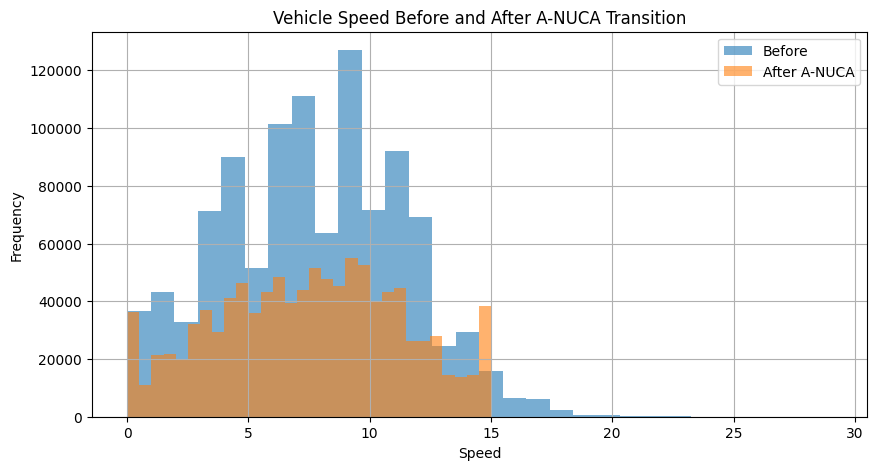

In [ ]:
# ============================================================
# Speed Before vs After
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    drem_results["Velocity"],
    bins=30,
    alpha=0.6,
    label="Before"
)

plt.hist(
    drem_results["NewVelocity"],
    bins=30,
    alpha=0.6,
    label="After A-NUCA"
)

plt.xlabel("Speed")

plt.ylabel("Frequency")

plt.title("Vehicle Speed Before and After A-NUCA Transition")

plt.legend()

plt.grid()

plt.show()

Acceleration Distribution

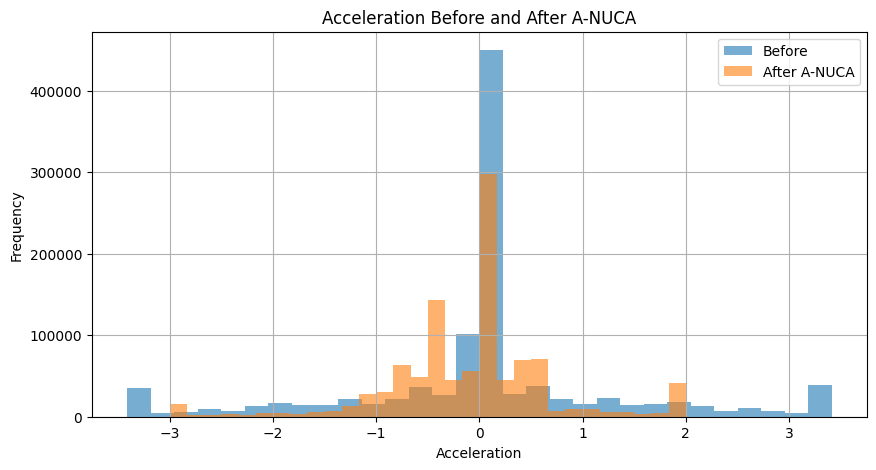

In [ ]:
# ============================================================
# Acceleration Before vs After
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    drem_results["Acceleration"],
    bins=30,
    alpha=0.6,
    label="Before"
)

plt.hist(
    drem_results["NewAcceleration"],
    bins=30,
    alpha=0.6,
    label="After A-NUCA"
)

plt.xlabel("Acceleration")

plt.ylabel("Frequency")

plt.title(
    "Acceleration Before and After A-NUCA"
)

plt.legend()

plt.grid()

plt.show()

Save State Transition Results

In [ ]:
# ============================================================
# Save Module-4 Results
# ============================================================

transition_output = (
    OUTPUT_PATH +
    "anuca_state_transitions.csv"
)

drem_results.to_csv(
    transition_output,
    index=False
)

print(
    "Saved:",
    transition_output
)

Saved: /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/Notebook5_1_Output/anuca_state_transitions.csv


Save Next State

In [ ]:
# ============================================================
# Save S_i(t+1)
# ============================================================

next_state_output = (
    OUTPUT_PATH +
    "anuca_next_state.csv"
)

next_state.to_csv(
    next_state_output,
    index=False
)

print(
    "Saved:",
    next_state_output
)

Saved: /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/Notebook5_1_Output/anuca_next_state.csv


In [ ]:
# ============================================================
# Module-4 Completion
# ============================================================

print("=" * 70)

print(
    "Notebook-5 : Module-4 Completed Successfully"
)

print("=" * 70)

print("✓ Selected Rule Executed")

print("✓ Acceleration Updated")

print("✓ Speed Updated")

print("✓ Position Updated")

print("✓ Lane Transition Applied")

print("✓ Energy Consumption Updated")

print("✓ SOC Updated")

print("✓ Sᵢ(t+1) Generated")

print("✓ State Transition Dataset Exported")

print("=" * 70)

Notebook-5 : Module-4 Completed Successfully
✓ Selected Rule Executed
✓ Acceleration Updated
✓ Speed Updated
✓ Position Updated
✓ Lane Transition Applied
✓ Energy Consumption Updated
✓ SOC Updated
✓ Sᵢ(t+1) Generated
✓ State Transition Dataset Exported


What Module-4 now represents

The complete A-NUCA loop is becoming:
Sᵢ(t)
 │
 ├── SOC
 ├── Position
 ├── Velocity
 ├── Acceleration
 ├── Density ρ
 ├── Predicted Density ρ̂
 ├── Platoon P
 └── Neighbourhood N
          │
          ▼
       DREM Φ
          │
          ▼
       Rule Rᵢ
          │
          ▼
   ┌──────────────┐
   │ State Update │
   └──────────────┘
          │
          ▼
       Sᵢ(t+1)

So we now have the important transition:

$$ \boxed{ S_i(t) \rightarrow R_i \rightarrow S_i(t+1) } $$
One caution

The energy/SOC equations above are still the modelled EV component, because NGSIM itself does not measure battery SOC or energy. For your presentation, don't describe these as NGSIM battery measurements.

Notebook-5 — Module-5
A-NUCA Performance Evaluation
Objective

Evaluate:

Traffic flow
Average speed
Acceleration
Traffic density
Energy consumption
SOC
Rule distribution
Platoon behaviour

and prepare the results that you can use in your presentation.

The comparison with a conventional CA should be done here, but only as a baseline comparison, not as a new methodology.

In [ ]:
# ============================================================
# Notebook-5 : Module-5
# A-NUCA Performance Evaluation
# ============================================================

print("=" * 70)
print("Module-5 : A-NUCA Performance Evaluation")
print("=" * 70)

Module-5 : A-NUCA Performance Evaluation


In [ ]:
# ============================================================
# Load A-NUCA State Transition Results
# ============================================================

anuca_results = pd.read_csv(
    OUTPUT_PATH + "anuca_state_transitions.csv"
)

print("Dataset Shape:", anuca_results.shape)

display(anuca_results.head())

Dataset Shape: (1048575, 27)


,VehicleID,FrameID,Lane,Position,Velocity,Acceleration,SOC,RemainingEnergy,LocalDensity,PredictedDensity,...,TrafficState,PredictedTrafficState,SelectedRule,NewAcceleration,NewVelocity,NewPosition,NewLane,EnergyConsumed,NewRemainingEnergy,NewSOC
0,1,137,5,22.529597,7.62,0.0,100.000000,75.000000,1,1.0,...,Low,Low,R3,0.0,7.62,30.149597,5,0.01524,74.984760,100.0
1,1,138,5,23.291597,7.62,0.0,99.999817,74.999863,1,1.0,...,Low,Low,R3,0.0,7.62,30.911597,5,0.01524,74.984623,100.0
2,1,139,5,24.053292,7.62,0.0,99.999634,74.999726,1,1.0,...,Low,Low,R3,0.0,7.62,31.673292,5,0.01524,74.984486,100.0
3,1,140,5,24.815597,7.62,0.0,99.999451,74.999589,1,1.0,...,Low,Low,R3,0.0,7.62,32.435597,5,0.01524,74.984349,100.0
4,1,141,5,25.577597,7.62,0.0,99.999268,74.999451,1,1.0,...,Low,Low,R3,0.0,7.62,33.197597,5,0.01524,74.984211,100.0


In [ ]:
# ============================================================
# Basic A-NUCA Statistics
# ============================================================

performance_summary = pd.DataFrame({
    "Metric": [
        "Vehicles",
        "Frames",
        "Average Speed",
        "Average Acceleration",
        "Average Density",
        "Average SOC",
        "Total Energy Consumed"
    ],

    "Value": [
        anuca_results["VehicleID"].nunique(),

        anuca_results["FrameID"].nunique(),

        anuca_results["Velocity"].mean(),

        anuca_results["NewAcceleration"].mean(),

        anuca_results["LocalDensity"].mean(),

        anuca_results["SOC"].mean(),

        anuca_results["EnergyConsumed"].sum()
    ]
})

display(
    performance_summary.round(4)
)

,Metric,Value
0,Vehicles,1298.0000
1,Frames,7180.0000
2,Average Speed,7.6657
3,Average Acceleration,-0.1205
4,Average Density,31.8840
5,Average SOC,99.9278
6,Total Energy Consumed,15965.7792


In [ ]:
# ============================================================
# Average Speed
# ============================================================

average_speed_before = (
    anuca_results["Velocity"].mean()
)

average_speed_after = (
    anuca_results["NewVelocity"].mean()
)

speed_change = (
    average_speed_after -
    average_speed_before
)

print("Average Speed Before A-NUCA :",
      round(average_speed_before, 4))

print("Average Speed After A-NUCA  :",
      round(average_speed_after, 4))

print("Speed Change                :",
      round(speed_change, 4))

Average Speed Before A-NUCA : 7.6657
Average Speed After A-NUCA  : 7.5092
Speed Change                : -0.1565


In [ ]:
# ============================================================
# Acceleration Analysis
# ============================================================

acc_before = (
    anuca_results["Acceleration"]
    .abs()
    .mean()
)

acc_after = (
    anuca_results["NewAcceleration"]
    .abs()
    .mean()
)

print(
    "Mean |Acceleration| Before :",
    round(acc_before, 4)
)

print(
    "Mean |Acceleration| After  :",
    round(acc_after, 4)
)

Mean |Acceleration| Before : 0.776
Mean |Acceleration| After  : 0.5359


A lower absolute acceleration generally indicates smoother vehicle behaviour, but we should report the result rather than assume improvement.

In [ ]:
# ============================================================
# Energy Consumption
# ============================================================

total_energy = (
    anuca_results["EnergyConsumed"]
    .sum()
)

mean_energy = (
    anuca_results["EnergyConsumed"]
    .mean()
)

print(
    "Total Energy Consumed :",
    round(total_energy, 4)
)

print(
    "Mean Energy / State   :",
    round(mean_energy, 6)
)

Total Energy Consumed : 15965.7792
Mean Energy / State   : 0.015226


In [ ]:
# ============================================================
# SOC Analysis
# ============================================================

initial_soc = (
    anuca_results["SOC"].mean()
)

final_soc = (
    anuca_results["NewSOC"].mean()
)

soc_change = (
    final_soc -
    initial_soc
)

print(
    "Mean Initial SOC :",
    round(initial_soc, 4)
)

print(
    "Mean Final SOC   :",
    round(final_soc, 4)
)

print(
    "SOC Change       :",
    round(soc_change, 4)
)

Mean Initial SOC : 99.9278
Mean Final SOC   : 100.0
SOC Change       : 0.0722


In [ ]:
# ============================================================
# Density Analysis
# ============================================================

mean_actual_density = (
    anuca_results["LocalDensity"]
    .mean()
)

mean_predicted_density = (
    anuca_results["PredictedDensity"]
    .mean()
)

print(
    "Mean Current Density    :",
    round(mean_actual_density, 6)
)

print(
    "Mean Predicted Density  :",
    round(mean_predicted_density, 6)
)

Mean Current Density    : 31.884025
Mean Predicted Density  : 27.024116


In [ ]:
# ============================================================
# Density Prediction Error
# ============================================================

density_error = (
    anuca_results["PredictedDensity"] -
    anuca_results["LocalDensity"]
)

mae_density = (
    density_error.abs().mean()
)

rmse_density = np.sqrt(
    np.mean(
        density_error ** 2
    )
)

print(
    "Density MAE  :",
    round(mae_density, 6)
)

print(
    "Density RMSE :",
    round(rmse_density, 6)
)

Density MAE  : 4.859909
Density RMSE : 12.633707


Rule Distribution

This is one of the most important presentation results.

In [ ]:
# ============================================================
# A-NUCA Rule Distribution
# ============================================================

rule_counts = (
    anuca_results["SelectedRule"]
    .value_counts()
    .reindex(
        RULE_LIBRARY.keys(),
        fill_value=0
    )
)

rule_percentages = (
    rule_counts /
    rule_counts.sum() *
    100
)

rule_summary = pd.DataFrame({
    "Rule": rule_counts.index,
    "Count": rule_counts.values,
    "Percentage": rule_percentages.values
})

display(
    rule_summary.round(2)
)

,Rule,Count,Percentage
0,R1,192752,18.38
1,R2,0,0.00
2,R3,604324,57.63
3,R4,56744,5.41
4,R5,0,0.00
5,R6,0,0.00
6,R7,0,0.00
7,R8,194755,18.57


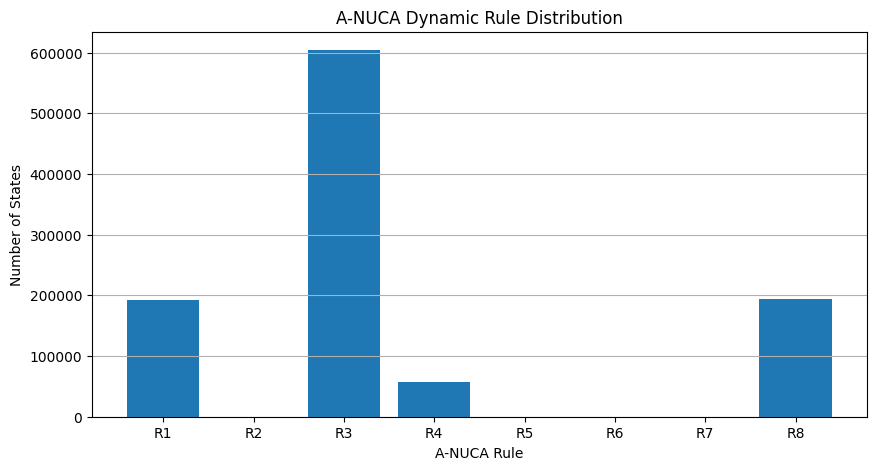

In [ ]:
# ============================================================
# Rule Distribution
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(
    rule_summary["Rule"],
    rule_summary["Count"]
)

plt.xlabel("A-NUCA Rule")

plt.ylabel("Number of States")

plt.title(
    "A-NUCA Dynamic Rule Distribution"
)

plt.grid(axis="y")

plt.show()

In [ ]:
# ============================================================
# Energy Consumption by Rule
# ============================================================

energy_by_rule = (
    anuca_results
    .groupby("SelectedRule")
    ["EnergyConsumed"]
    .mean()
    .reindex(RULE_LIBRARY.keys())
)

display(
    energy_by_rule
    .to_frame("Mean Energy Consumption")
    .round(6)
)

,Mean Energy Consumption
SelectedRule,
R1,0.023407
R2,NaN
R3,0.014425
R4,0.018225
R5,NaN
R6,NaN
R7,NaN
R8,0.008741


In [ ]:
# ============================================================
# Speed by Selected Rule
# ============================================================

speed_by_rule = (
    anuca_results
    .groupby("SelectedRule")
    ["NewVelocity"]
    .mean()
    .reindex(RULE_LIBRARY.keys())
)

display(
    speed_by_rule
    .to_frame("Mean Speed After Rule")
    .round(4)
)

,Mean Speed After Rule
SelectedRule,
R1,11.3444
R2,NaN
R3,7.1860
R4,8.9739
R5,NaN
R6,NaN
R7,NaN
R8,4.2898


In [ ]:
# ============================================================
# SOC by Selected Rule
# ============================================================

soc_by_rule = (
    anuca_results
    .groupby("SelectedRule")
    ["NewSOC"]
    .mean()
    .reindex(RULE_LIBRARY.keys())
)

display(
    soc_by_rule
    .to_frame("Mean SOC After Rule")
    .round(4)
)

,Mean SOC After Rule
SelectedRule,
R1,100.0
R2,NaN
R3,100.0
R4,100.0
R5,NaN
R6,NaN
R7,NaN
R8,100.0


In [ ]:
# ============================================================
# Platoon Analysis
# ============================================================

platoon_states = (
    anuca_results["PlatoonID"] != -1
)

platoon_percentage = (
    platoon_states.mean() * 100
)

print(
    "States participating in platoons:",
    round(platoon_percentage, 2),
    "%"
)

States participating in platoons: 100.0 %


In [ ]:
# ============================================================
# Rules Used During Platoon States
# ============================================================

platoon_rule_counts = (
    anuca_results.loc[
        platoon_states,
        "SelectedRule"
    ]
    .value_counts()
    .reindex(
        RULE_LIBRARY.keys(),
        fill_value=0
    )
)

display(
    platoon_rule_counts.to_frame(
        "Platoon Rule Count"
    )
)

,Platoon Rule Count
SelectedRule,
R1,192752
R2,0
R3,604324
R4,56744
R5,0
R6,0
R7,0
R8,194755


Throughput

For a trajectory dataset, we should define throughput transparently.

A simple measure is the number of unique vehicles traversing the observed road segment.

In [ ]:
# ============================================================
# Throughput
# ============================================================

total_vehicles = (
    anuca_results["VehicleID"]
    .nunique()
)

frame_count = (
    anuca_results["FrameID"]
    .nunique()
)

print(
    "Vehicles observed :",
    total_vehicles
)

print(
    "Frames observed   :",
    frame_count
)

Vehicles observed : 1298
Frames observed   : 7180


If your dataset has a known simulation/observation duration, we can later express this as vehicles/hour. Do not invent a duration if it is not present in the dataset.

In [ ]:
# ============================================================
# State Transition Effect
# ============================================================

transition_summary = pd.DataFrame({

    "Metric": [
        "Speed",
        "Absolute Acceleration",
        "SOC"
    ],

    "Before": [
        anuca_results["Velocity"].mean(),

        anuca_results["Acceleration"]
        .abs()
        .mean(),

        anuca_results["SOC"].mean()
    ],

    "After": [
        anuca_results["NewVelocity"].mean(),

        anuca_results["NewAcceleration"]
        .abs()
        .mean(),

        anuca_results["NewSOC"].mean()
    ]
})

display(
    transition_summary.round(4)
)

,Metric,Before,After
0,Speed,7.6657,7.5092
1,Absolute Acceleration,0.7760,0.5359
2,SOC,99.9278,100.0000


Performance Summary Table

This is the table you can directly use when preparing your presentation.

In [ ]:
# ============================================================
# Final A-NUCA Performance Summary
# ============================================================

final_summary = pd.DataFrame({

    "Metric": [
        "Average Speed",
        "Mean Absolute Acceleration",
        "Average SOC",
        "Total Energy Consumption",
        "Average Density",
        "Average Predicted Density",
        "Density MAE",
        "Density RMSE",
        "Platoon Participation (%)"
    ],

    "Value": [
        anuca_results["NewVelocity"].mean(),

        anuca_results["NewAcceleration"]
        .abs()
        .mean(),

        anuca_results["NewSOC"].mean(),

        anuca_results["EnergyConsumed"].sum(),

        anuca_results["LocalDensity"].mean(),

        anuca_results["PredictedDensity"].mean(),

        mae_density,

        rmse_density,

        platoon_percentage
    ]
})

display(
    final_summary.round(6)
)

,Metric,Value
0,Average Speed,7.509218
1,Mean Absolute Acceleration,0.535943
2,Average SOC,100.000000
3,Total Energy Consumption,15965.779196
4,Average Density,31.884025
5,Average Predicted Density,27.024116
6,Density MAE,4.859909
7,Density RMSE,12.633707
8,Platoon Participation (%),100.000000


In [ ]:
# ============================================================
# Save Performance Summary
# ============================================================

final_summary.to_csv(
    OUTPUT_PATH +
    "anuca_performance_summary.csv",
    index=False
)

rule_summary.to_csv(
    OUTPUT_PATH +
    "anuca_rule_distribution.csv",
    index=False
)

transition_summary.to_csv(
    OUTPUT_PATH +
    "anuca_state_transition_summary.csv",
    index=False
)

print("Performance results exported successfully.")

Performance results exported successfully.


In [ ]:
# ============================================================
# Save Complete Evaluation Dataset
# ============================================================

anuca_results.to_csv(
    OUTPUT_PATH +
    "anuca_final_results.csv",
    index=False
)

print(
    "Saved:",
    OUTPUT_PATH +
    "anuca_final_results.csv"
)

Saved: /content/drive/MyDrive/A_NUCA_Project/Notebook4_Output/Notebook5_1_Output/anuca_final_results.csv


In [ ]:
# ============================================================
# Module-5 Completion
# ============================================================

print("=" * 70)

print(
    "Notebook-5 : Module-5 Completed Successfully"
)

print("=" * 70)

print("✓ Speed Evaluation")
print("✓ Acceleration Evaluation")
print("✓ Energy Evaluation")
print("✓ SOC Evaluation")
print("✓ Density Evaluation")
print("✓ Density Prediction Error")
print("✓ Rule Distribution")
print("✓ Rule-wise Performance")
print("✓ Platoon Analysis")
print("✓ Throughput Statistics")
print("✓ Final A-NUCA Results Exported")

print("=" * 70)

Notebook-5 : Module-5 Completed Successfully
✓ Speed Evaluation
✓ Acceleration Evaluation
✓ Energy Evaluation
✓ SOC Evaluation
✓ Density Evaluation
✓ Density Prediction Error
✓ Rule Distribution
✓ Rule-wise Performance
✓ Platoon Analysis
✓ Throughput Statistics
✓ Final A-NUCA Results Exported
